In [1]:
import torch as th
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

import sys
sys.path.append('..')

In [2]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, batch_first=False):
        super(LSTMEncoder, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=batch_first)
        self.hidden_to_mu = nn.Linear(hidden_dim, latent_dim)
        self.hidden_to_logvar = nn.Linear(hidden_dim, latent_dim)

        #self.hx = None # hidden and cell states (h_n, c_n) or None
    
    def forward(self, x):
        # Apply the LSTM to the input sequence x
        output_sequence, (hidden, cell) = self.lstm(x)

        # Compute mean and log variance for the latent space
        mu = self.hidden_to_mu(hidden)
        logvar = self.hidden_to_logvar(hidden)

        return mu, logvar

In [ ]:
encoder = LSTMEncoder(input_dim=9, hidden_dim=32, latent_dim=3, num_layers=1)
encoder

In [ ]:
seq_len = 10
num_features = 9
x = th.ones(seq_len, num_features)

mu, logvar = encoder(x)
mu, logvar

In [ ]:
z = mu + logvar

#z = z.repeat(seq_len, 1)
z
#z = z.view(batch_size, seq_len, self.latent_size).to(self.device)

In [3]:
class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, num_layers, batch_first=False):
        super(LSTMDecoder, self).__init__()
        
        self.fc_latent_hidden = nn.Linear(latent_dim, hidden_dim)
        self.lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=batch_first)
        self.fc_hidden_output = nn.Linear(hidden_dim, output_dim)

        self.seq_len = None
    
    def forward(self, z):

        z_sequence = z.repeat(seq_len, 1)

        hidden = self.fc_latent_hidden(z)
        
        prediction, (hidden, cell) = self.lstm(z_sequence, (hidden, th.zeros_like(hidden)))
        
        reconstruction = self.fc_hidden_output(prediction)

        return reconstruction

In [ ]:
decoder = LSTMDecoder(latent_dim=3, hidden_dim=32, output_dim=9, num_layers=1)
decoder.seq_len = seq_len

decoder(z)

In [4]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        
        self.encoder = encoder # maps input to latent space
        self.decoder = decoder # reconstruct input from latent space
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) using
        a standard normal distribution and allowing gradients to flow through.
        """
        std = th.exp(0.5 * logvar) # Compute the standard deviation by exponentiating half the log variance
        eps = th.randn_like(std)   # Sample noise from a standard normal distribution (mean=0, std=1)

        latent_space_sample = mu + eps * std # Generate a sample from the latent space by adding scaled noise to the mean

        return latent_space_sample
    
    def forward(self, x):
        mu, logvar = self.encode(x) 
        z = self.reparameterize(mu, logvar) # Sample a latent variable using reparameterization trick

        self.decoder.seq_len = x.shape[0]
        x_reconstructed = self.decode(z)

        return x_reconstructed, mu, logvar
    
    def encode(self, x):
        mu, logvar = self.encoder(x)        # Pass input through encoder to get mean and log variance of latent space

        return mu, logvar
    
    def decode(self, z):
        x_reconstructed = self.decoder(z)   # Feed the sampled latent variable through decoder to reconstruct input

        return x_reconstructed

In [5]:
from aux_data import *

"""
1) LOAD DATASETS
"""
# Load datasets for sensor voltage and robot positions
data_dir_path = '../data/SoftText/'
dataset_names = ['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat',  'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

# Concatenate pressure dataset
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 'dataset_act_sens_pos_2.mat', 'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures

In [6]:
TR_IDX = 3
VL_IDX = 1
TS_IDX = 2
# Training
training_dataset = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_IDX]
validation_dataset = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_IDX]
test_dataset = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_IDX]

tr_pressure, tr_sensor, tr_tip_position = training_dataset['pressure'], training_dataset['sensor_resistance'], training_dataset['tip_position']

X_to_scale = np.concatenate((tr_pressure, tr_sensor, tr_tip_position), axis=1) # (n_samples, features)
observation_scaler = StandardScaler().fit(X_to_scale)

X_pr = np.concatenate((tr_pressure, tr_sensor), axis=1)
X_pr = exponential_moving_average(X_pr, alpha=np.array([0.6, 0.6, 0.6, 0.4, 0.4, 0.4]))

X_tr = np.concatenate((X_pr, tr_tip_position), axis=1) # (n_samples, features)
X_tr = th.tensor(observation_scaler.transform(X_tr), dtype=th.float32)
X_tr.shape


torch.Size([16201, 9])

In [7]:
seq_len = 50
X_tr_unfold = X_tr.unfold(dimension=0, size=seq_len, step=seq_len) # (time, 9, seq_len)
X_tr_unfold = X_tr_unfold.transpose(-2, -1) # (time, seq_len, 3)

X_tr_unfold.shape

torch.Size([324, 50, 9])

In [8]:
encoder = LSTMEncoder(input_dim=9, hidden_dim=32, latent_dim=3, num_layers=1)
decoder = LSTMDecoder(latent_dim=3, hidden_dim=32, output_dim=9, num_layers=1)
decoder.seq_len = seq_len

vae = VAE(encoder, decoder)
vae

VAE(
  (encoder): LSTMEncoder(
    (lstm): LSTM(9, 32)
    (hidden_to_mu): Linear(in_features=32, out_features=3, bias=True)
    (hidden_to_logvar): Linear(in_features=32, out_features=3, bias=True)
  )
  (decoder): LSTMDecoder(
    (fc_latent_hidden): Linear(in_features=3, out_features=32, bias=True)
    (lstm): LSTM(3, 32)
    (fc_hidden_output): Linear(in_features=32, out_features=9, bias=True)
  )
)

In [9]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = th.optim.Adam(vae.parameters(), lr=1e-4, weight_decay=1e-4)

In [10]:
n_epochs = 500
losses = []

for i in tqdm(range(n_epochs)):
    n_sequences = X_tr_unfold.shape[0]
    series_losses = np.zeros(n_sequences)  # store losses

    for i, x in enumerate(X_tr_unfold):
        # Clear accumulated gradient before each instance
        optimizer.zero_grad()

        # Forward pass
        x_prime, mu, logvar = vae(x) # y_hat is (sequence_len, 3)

        # Compute the loss, the loss gradients, and update the parameters with the optimizer
        loss = criterion(x, x_prime)
        loss.backward()
        optimizer.step()

        # detach() returns a new Tensor detached from the current graph (it will not require gradient) 
        series_losses[i] = loss.detach().numpy()
    
    losses.append(np.mean(series_losses))

100%|██████████| 500/500 [08:36<00:00,  1.03s/it]


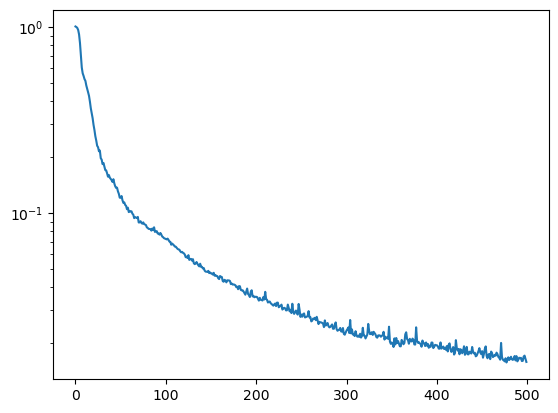

In [11]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.yscale('log')

In [12]:
vae.eval()
#vae.decoder.seq_len = X_tr.shape[0]
X_prime = th.zeros_like(X_tr_unfold)

for i, x in enumerate(X_tr_unfold):
    x_prime, _, _ = vae(x)
    X_prime[i] = x_prime

In [13]:
X_prime = X_prime.view(-1, X_tr.shape[-1])
X_prime.shape

torch.Size([16200, 9])

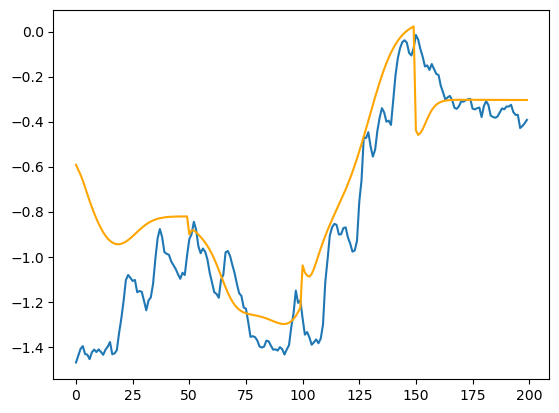

In [14]:
plt.plot(X_tr[:200,4].detach().numpy())
plt.plot(X_prime[:200,4].detach().numpy(), color='orange')